In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
Lx = 2*np.pi
Ly = 2*np.pi

Nx = 128
Ny = 128

nu = 0.01
t = 0.0
dt = 0.1

x = np.linspace(0,Lx,Nx,endpoint=False)
y = np.linspace(0,Ly,Ny,endpoint=False)

X,Y = np.meshgrid(x,y,indexing="ij")

h = Lx/Nx

In [3]:
def velocity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    u = np.sin(x)*np.cos(y)*decay
    v = -np.cos(x)*np.sin(y)*decay
    return u,v

def vorticity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    return 2*np.sin(x)*np.sin(y)*decay

In [4]:
W = vorticity(X,Y, t, nu)

In [ ]:
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), W.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

In [44]:
for i in range(len(particles)):
    u = 0
    v = 0
    for j in range(len(particles)):
        if i != j:
            u += (particles[j]['a'] / 2*np.pi) * (particles[i]['pos'] - particles[j]['pos'] / np.square(abs(particles[i]['pos'] - particles[j]['pos'])))
            #v += (particles[j]['a'] / 2*np.pi) * ((particles[i]['y'] - particles[j]['y']) / np.square(particles[i]['y'] - particles[j]['y']))

    particles[i]['u'] = u



In [45]:
for p in particles:
    p['pos'] += p['u'] * dt

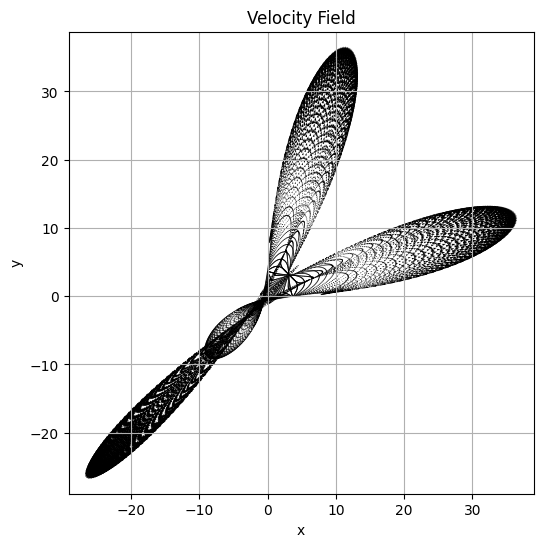

In [47]:
import matplotlib.pyplot as plt

# Extract data
x = [p["pos"].real for p in particles]
y = [p["pos"].imag for p in particles]

u = [p["u"].real for p in particles]
v = [p["u"].imag for p in particles]

# Plot velocity vectors
plt.figure(figsize=(6,6))
plt.quiver(x, y, u, v)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Velocity Field")
plt.axis("equal")
plt.grid(True)

plt.show()